In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import RandomizedSearchCV

import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the Dataset
df = pd.read_csv("Order_delivery.csv")

df.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,16-06-2025 08:32,16-06-2025 09:11,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,03-06-2025 21:27,03-06-2025 22:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,01-06-2025 14:48,01-06-2025 15:26,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,13-06-2025 02:30,13-06-2025 03:22,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,06-06-2025 09:48,06-06-2025 10:32,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


In [4]:
#Basic Dataset Information

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (100002, 23)

Columns:
['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name', 'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time', 'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status', 'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'Traffic_Level', 'Driver_Availability']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100002 entries, 0 to 100001
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100002 non-null  int64  
 1   User_ID                    100002 non-null  object 
 2   Restaurant_ID              100002 non-null  int64  
 3   Driver_ID                  100002 non-null  int64  
 4   Item_Name                  100002 non-null  object 
 5   Quantity                   100002 non-null  int64  

In [5]:
#Statistical Summary
df.describe()

,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km
count,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.00000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000
mean,50001.500000,499.832513,250.792414,2.991100,268.922678,37.52021,30.119025,31.063056,30.119070,31.062962,30.119086,31.062983,2.165299
std,28868.235147,288.253044,144.288871,1.410121,170.490102,10.06083,1.271630,0.487763,1.271666,0.487819,1.271690,0.487834,1.038464
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.00000,27.160900,29.898701,27.160900,29.898706,27.160901,29.898703,0.008839
25%,25001.250000,250.000000,126.000000,2.000000,129.430000,30.00000,30.023110,31.008774,30.023371,31.008460,30.023297,31.008408,1.355612
50%,50001.500000,499.000000,251.000000,3.000000,233.200000,38.00000,30.587306,31.209099,30.587054,31.208817,30.587085,31.209075,2.122694
75%,75001.750000,750.000000,376.000000,4.000000,381.507500,45.00000,31.026914,31.371673,31.027115,31.371856,31.027242,31.371506,2.924524
max,100002.000000,1000.000000,500.000000,5.000000,750.000000,60.00000,31.220099,31.521997,31.220096,31.521995,31.220099,31.521999,5.597928


In [6]:
# For categorical columns:
df.describe(include="object")

,User_ID,Item_Name,Order_Time,Delivery_Time,City,Payment_Method,Order_Status,Driver_Vehicle,Traffic_Level,Driver_Availability
count,100002,100002,100002,100002,100002,100002,100002,100002,100002,100002
unique,9000,9,21367,21396,7,3,3,3,3,2
top,U1071,Shawarma,07-06-2025 07:23,09-06-2025 21:20,Zagazig,Cash,Delivered,Bicycle,Low,Online
freq,26,11320,16,15,14538,33528,85199,33393,45826,90113


In [7]:
#Check Missing Values
df.isnull().sum()

Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

For your current dataset, there are no missing values.

In [8]:
#Check Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
#Unique Values and Number of Unique Values
for column in df.columns:
    print("\nColumn:", column)
    print("Unique Count:", df[column].nunique())
    
    if df[column].nunique() <= 20:
        print(df[column].unique())


Column: Order_ID
Unique Count: 100002

Column: User_ID
Unique Count: 9000

Column: Restaurant_ID
Unique Count: 1000

Column: Driver_ID
Unique Count: 500

Column: Item_Name
Unique Count: 9
['Fried Chicken' 'Sandwich' 'Koshary' 'Sushi' 'Shawarma' 'Pizza' 'Burger'
 'Salad' 'Pasta']

Column: Quantity
Unique Count: 5
[3 2 5 1 4]

Column: Total_Price
Unique Count: 35618

Column: Order_Time
Unique Count: 21367

Column: Delivery_Time
Unique Count: 21396

Column: Delivery_Duration_Minutes
Unique Count: 46

Column: City
Unique Count: 7
['Alexandria' 'Zagazig' 'Assiut' 'Mansoura' 'Cairo' 'Tanta' 'Giza']

Column: Payment_Method
Unique Count: 3
['Wallet' 'Credit Card' 'Cash']

Column: Order_Status
Unique Count: 3
['Delivered' 'In Transit' 'Cancelled']

Column: Driver_Vehicle
Unique Count: 3
['Motorbike' 'Car' 'Bicycle']

Column: Restaurant_Lat
Unique Count: 99833

Column: Restaurant_Lon
Unique Count: 99785

Column: Customer_Lat
Unique Count: 99840

Column: Customer_Lon
Unique Count: 99780

Column:

In [10]:
#Convert Date and Time Columns
df["Order_Time"] = pd.to_datetime(
    df["Order_Time"],
    errors="coerce"
)

df["Delivery_Time"] = pd.to_datetime(
    df["Delivery_Time"],
    errors="coerce"
)

In [11]:
df[["Order_Time", "Delivery_Time"]].head()

,Order_Time,Delivery_Time
0,2025-06-16 08:32:00,2025-06-16 09:11:00
1,2025-06-03 21:27:00,2025-06-03 22:00:00
2,2025-06-01 14:48:00,2025-06-01 15:26:00
3,2025-06-13 02:30:00,2025-06-13 03:22:00
4,2025-06-06 09:48:00,2025-06-06 10:32:00


In [12]:
#Feature Engineering from Order Time
df["Order_Hour"] = df["Order_Time"].dt.hour
df["Order_Day"] = df["Order_Time"].dt.day
df["Order_Month"] = df["Order_Time"].dt.month
df["Order_DayOfWeek"] = df["Order_Time"].dt.dayofweek

In [13]:
df[
    [
        "Order_Time",
        "Order_Hour",
        "Order_Day",
        "Order_Month",
        "Order_DayOfWeek"
    ]
].head()

,Order_Time,Order_Hour,Order_Day,Order_Month,Order_DayOfWeek
0,2025-06-16 08:32:00,8,16,6,0
1,2025-06-03 21:27:00,21,3,6,1
2,2025-06-01 14:48:00,14,1,6,6
3,2025-06-13 02:30:00,2,13,6,4
4,2025-06-06 09:48:00,9,6,6,4


In [15]:
#Outlier Detection
numerical_check = [
    "Quantity",
    "Total_Price",
    "Delivery_Distance_km",
    "Delivery_Duration_Minutes"
]

for column in numerical_check:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(
        column,
        "Outliers:",
        len(outliers)
    )

Quantity Outliers: 0
Total_Price Outliers: 0
Delivery_Distance_km Outliers: 30
Delivery_Duration_Minutes Outliers: 0


In [16]:
#Check Skewness
numeric_columns = [
    "Quantity",
    "Total_Price",
    "Delivery_Distance_km",
    "Delivery_Duration_Minutes"
]

for column in numeric_columns:
    print(
        column,
        "Skewness:",
        df[column].skew()
    )

Quantity Skewness: 0.010817573628602072
Total_Price Skewness: 0.7741975135931347
Delivery_Distance_km Skewness: 0.202730806396853
Delivery_Duration_Minutes Skewness: 0.0016116643400692716


The target Delivery_Duration_Minutes in your dataset has a skewness very close to 0, so it is approximately symmetric.

In [17]:
#Exploratory Data Analysis – EDA

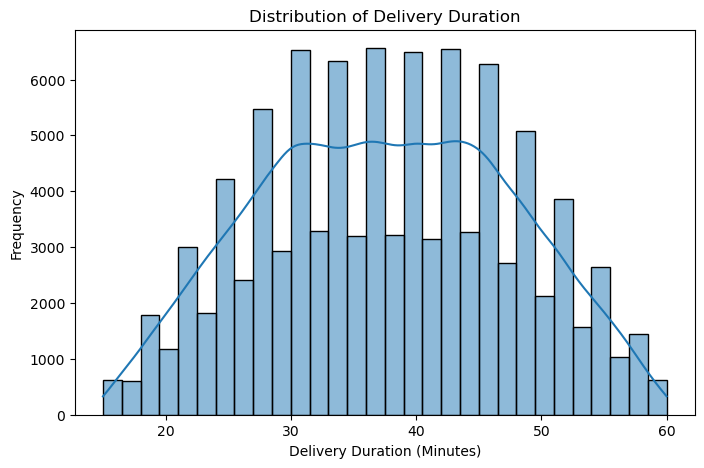

In [18]:
# Histogram

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Delivery_Duration_Minutes"],
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Duration")
plt.xlabel("Delivery Duration (Minutes)")
plt.ylabel("Frequency")

plt.show()

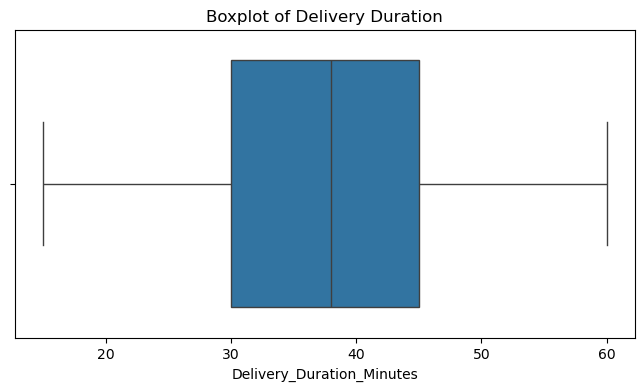

In [20]:
# Box Plot


plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["Delivery_Duration_Minutes"]
)

plt.title("Boxplot of Delivery Duration")

plt.show()

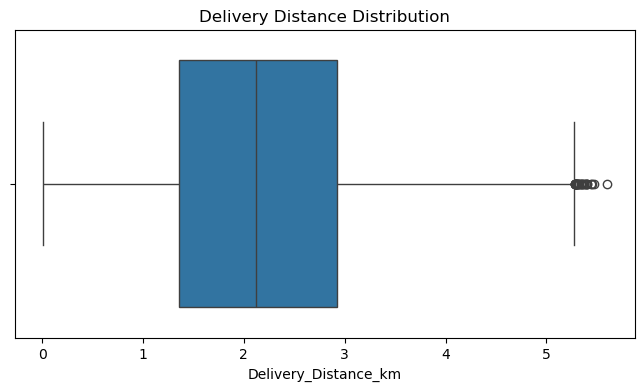

In [21]:
# Delivery Distance Boxplot

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["Delivery_Distance_km"]
)

plt.title("Delivery Distance Distribution")

plt.show()

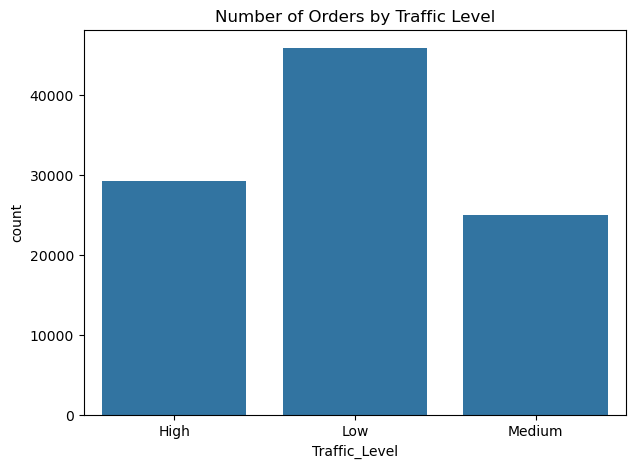

In [22]:
# Count Plot – Traffic Level

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Traffic_Level",
    data=df
)

plt.title("Number of Orders by Traffic Level")

plt.show()

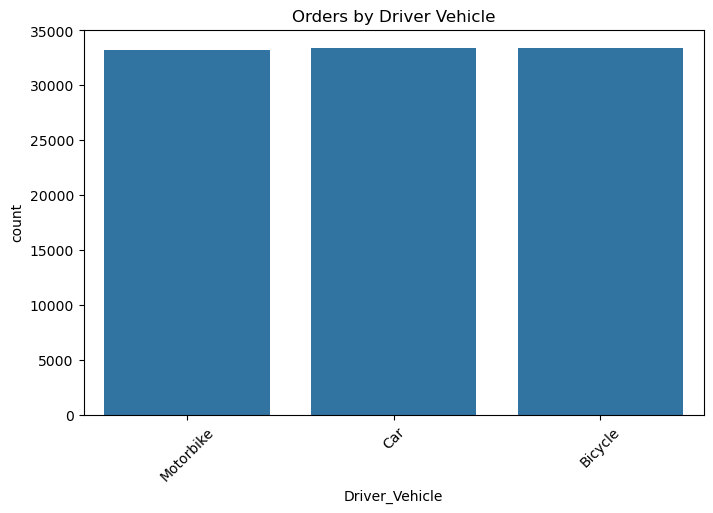

In [23]:
#   Count Plot – Driver Vehicle

plt.figure(figsize=(8, 5))

sns.countplot(
    x="Driver_Vehicle",
    data=df
)

plt.title("Orders by Driver Vehicle")

plt.xticks(rotation=45)

plt.show()

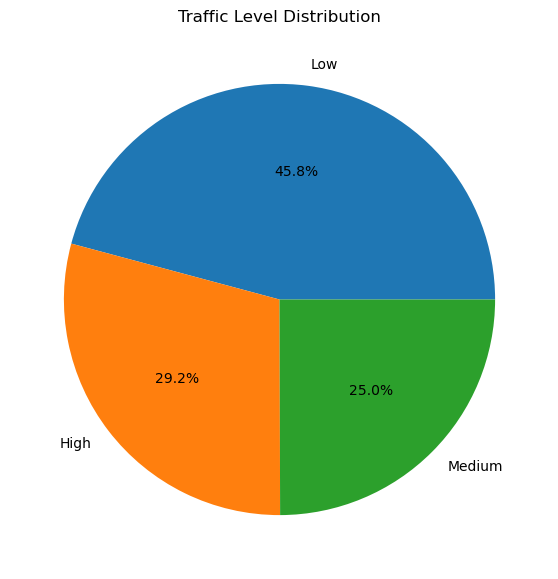

In [24]:
# Pie Chart – Traffic Levels

traffic_count = df["Traffic_Level"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    traffic_count,
    labels=traffic_count.index,
    autopct="%1.1f%%"
)

plt.title("Traffic Level Distribution")

plt.show()

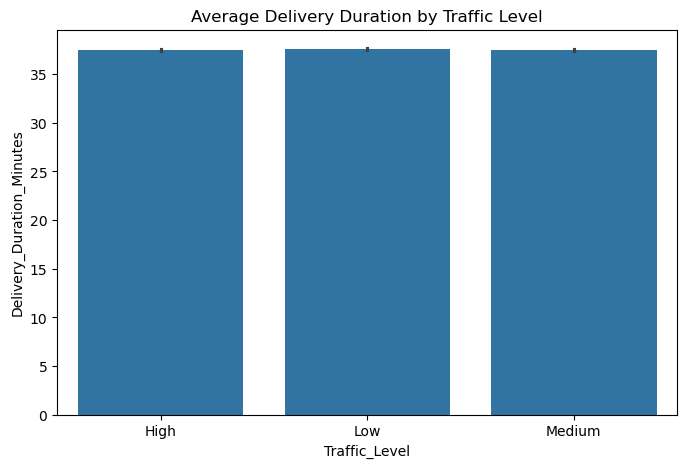

In [25]:
#   Bar Plot – Average Delivery Time by Traffic Level

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Traffic_Level",
    y="Delivery_Duration_Minutes",
    data=df
)

plt.title(
    "Average Delivery Duration by Traffic Level"
)

plt.show()

This helps determine whether high traffic increases delivery time.

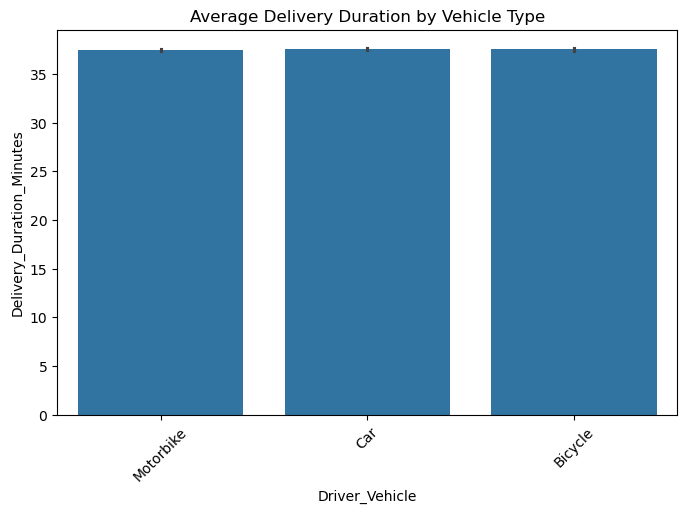

In [27]:
#  Average Delivery Time by Vehicle Type

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Driver_Vehicle",
    y="Delivery_Duration_Minutes",
    data=df
)

plt.title(
    "Average Delivery Duration by Vehicle Type"
)

plt.xticks(rotation=45)

plt.show()

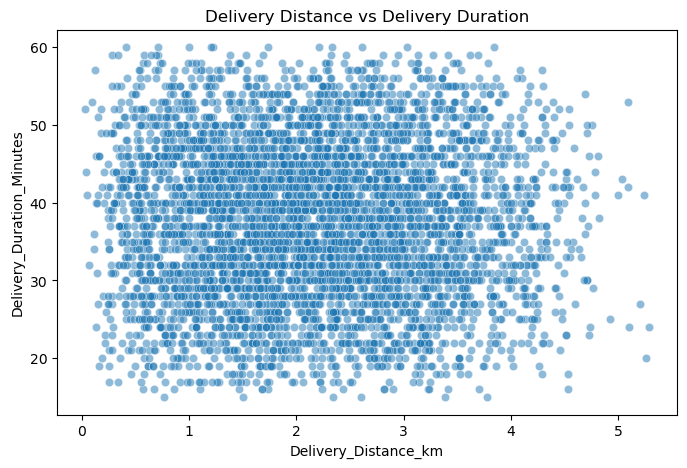

In [28]:
#  Distance vs Delivery Duration

sample_df = df.sample(
    5000,
    random_state=42
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Delivery_Distance_km",
    y="Delivery_Duration_Minutes",
    data=sample_df,
    alpha=0.5
)

plt.title(
    "Delivery Distance vs Delivery Duration"
)

plt.show()

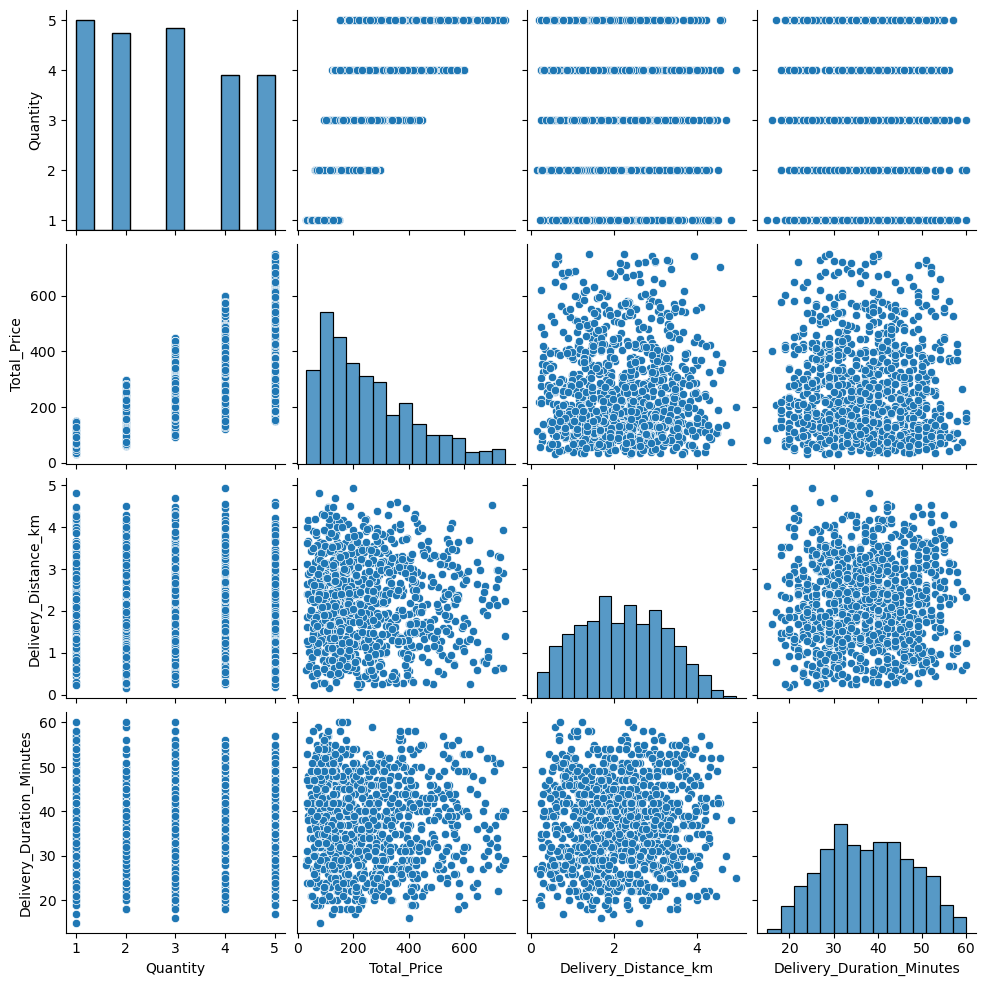

In [29]:
#   Pair Plot

pair_data = df[
    [
        "Quantity",
        "Total_Price",
        "Delivery_Distance_km",
        "Delivery_Duration_Minutes"
    ]
].sample(
    1000,
    random_state=42
)

sns.pairplot(pair_data)

plt.show()

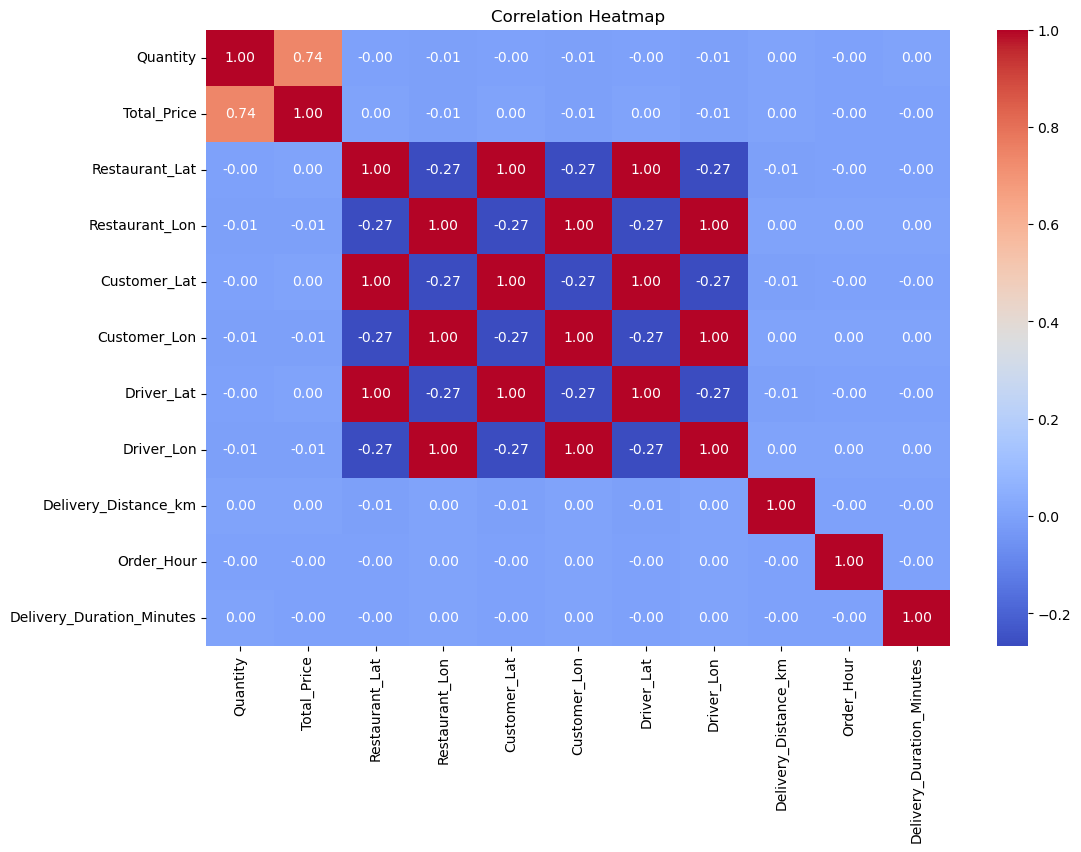

In [30]:
#   Correlation Heatmap


correlation_columns = [
    "Quantity",
    "Total_Price",
    "Restaurant_Lat",
    "Restaurant_Lon",
    "Customer_Lat",
    "Customer_Lon",
    "Driver_Lat",
    "Driver_Lon",
    "Delivery_Distance_km",
    "Order_Hour",
    "Delivery_Duration_Minutes"
]

corr = df[
    correlation_columns
].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

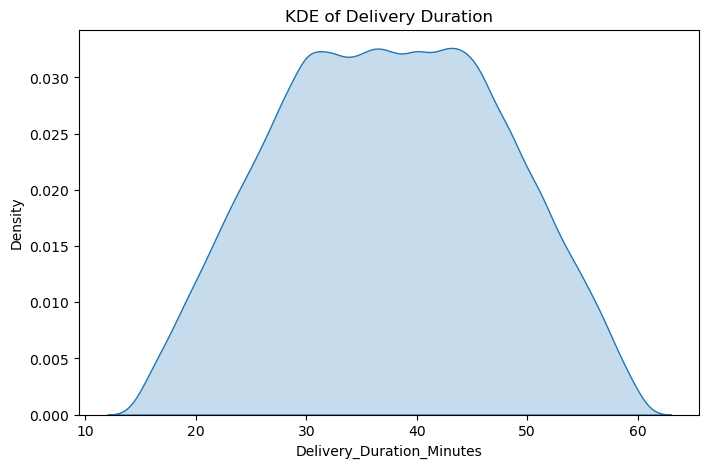

In [31]:
#  KDE Plot


plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x="Delivery_Duration_Minutes",
    fill=True
)

plt.title(
    "KDE of Delivery Duration"
)

plt.show()

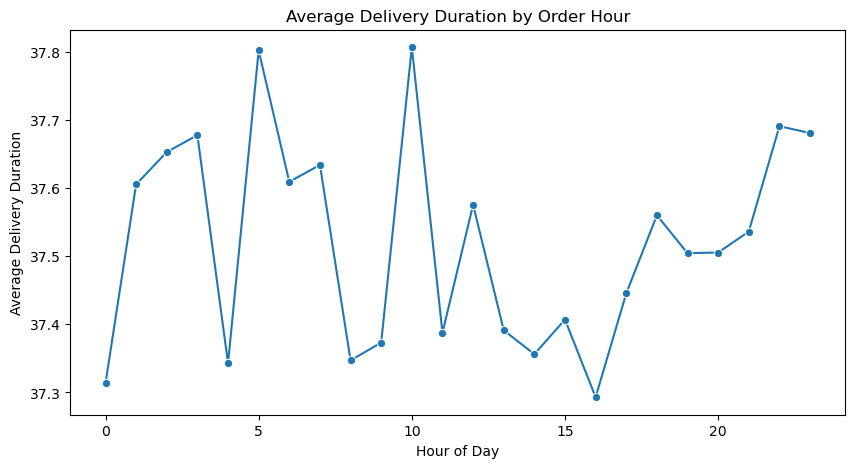

In [32]:
#  Line Plot – Average Delivery Duration by Hour


hourly_delivery = (
    df.groupby("Order_Hour")[
        "Delivery_Duration_Minutes"
    ]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x="Order_Hour",
    y="Delivery_Duration_Minutes",
    data=hourly_delivery,
    marker="o"
)

plt.title(
    "Average Delivery Duration by Order Hour"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Delivery Duration")

plt.show()

Select Features for Machine Learning

We should remove identifier columns because they don't represent meaningful predictive information.

Order_ID
User_ID
Restaurant_ID
Driver_ID

We should also avoid:

Delivery_Time
Order_Status
Delivery_Duration_Minutes


because of leakage/target issues.



In [35]:
# For the first model, use:

features = [
    "Quantity",
    "Total_Price",
    "City",
    "Payment_Method",
    "Driver_Vehicle",
    "Delivery_Distance_km",
    "Traffic_Level",
    "Driver_Availability",
    "Order_Hour",
    "Order_DayOfWeek"
]

target = "Delivery_Duration_Minutes"

In [36]:
#  Create X and y:

X = df[features]

y = df[target]

In [37]:
# Numerical and Categorical Features

numerical_features = [
    "Quantity",
    "Total_Price",
    "Delivery_Distance_km",
    "Order_Hour",
    "Order_DayOfWeek"
]

categorical_features = [
    "City",
    "Payment_Method",
    "Driver_Vehicle",
    "Traffic_Level",
    "Driver_Availability"
]

In [38]:
#  Split into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (80001, 10)
Testing Shape: (20001, 10)


Create Data Preprocessing Pipeline
This handles:

- StandardScaler for numerical columns
- OneHotEncoder for categorical columns

In [40]:
numeric_transformer = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [41]:
#  Model Evaluation Function


def evaluate_model(
    model_name,
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        actual,
        predicted
    )

    print("\n", model_name)

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [42]:
#   Linear Regression

linear_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_pipeline.fit(
    X_train,
    y_train
)

linear_pred = linear_pipeline.predict(
    X_test
)

In [44]:
# Evaluate

linear_result = evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)


 Linear Regression
MAE : 8.379259719863605
MSE : 100.20285011613454
RMSE: 10.01013736749574
R2  : -6.932825333239023e-05


In [45]:
# Random Forest Regressor

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=15,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

rf_pred = rf_pipeline.predict(
    X_test
)

In [46]:
#  Evaluation:

rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)


 Random Forest
MAE : 8.38900481251326
MSE : 100.5322513805497
RMSE: 10.026577251512586
R2  : -0.0033569004216653653


In [47]:
#  Gradient Boosting Regressor


gb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

gb_pipeline.fit(
    X_train,
    y_train
)

gb_pred = gb_pipeline.predict(
    X_test
)

In [48]:
# Evaluation:

gb_result = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred
)


 Gradient Boosting
MAE : 8.380861969988446
MSE : 100.26942550501913
RMSE: 10.013462213691083
R2  : -0.0007337804556684091


In [50]:
#  AdaBoost Regressor

ada_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            AdaBoostRegressor(
                random_state=42
            )
        )
    ]
)

ada_pipeline.fit(
    X_train,
    y_train
)

ada_pred = ada_pipeline.predict(
    X_test
)

In [51]:
#  Evaluation:

ada_result = evaluate_model(
    "AdaBoost",
    y_test,
    ada_pred
)


 AdaBoost
MAE : 8.379232804203442
MSE : 100.20844586072596
RMSE: 10.010416867479893
R2  : -0.0001251762908696108


Support Vector Regression – SVR
Since SVR can be slow with 100,000 records, it's better for a student project to train it on a representative subset

In [52]:
X_train_svr = X_train.sample(
    20000,
    random_state=42
)

y_train_svr = y_train.loc[
    X_train_svr.index
]

In [53]:
# Model:

svr_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            SVR(
                kernel="rbf"
            )
        )
    ]
)

svr_pipeline.fit(
    X_train_svr,
    y_train_svr
)

svr_pred = svr_pipeline.predict(
    X_test
)

In [55]:
#  Evaluation:

svr_result = evaluate_model(
    "SVR",
    y_test,
    svr_pred
)


 SVR
MAE : 8.417883284867473
MSE : 101.41956279639948
RMSE: 10.070728017199128
R2  : -0.012212665807300072


In [57]:
# MLP Regressor

mlp_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(64, 32),
                max_iter=300,
                random_state=42
            )
        )
    ]
)

mlp_pipeline.fit(
    X_train,
    y_train
)

mlp_pred = mlp_pipeline.predict(
    X_test
)

In [58]:
# Evaluation:

mlp_result = evaluate_model(
    "MLP Regressor",
    y_test,
    mlp_pred
)


 MLP Regressor
MAE : 8.390562386014324
MSE : 100.66125470833921
RMSE: 10.033008258161617
R2  : -0.0046444114177639495


Compare All Models


In [59]:
results = pd.DataFrame(
    [
        linear_result,
        rf_result,
        gb_result,
        ada_result,
        svr_result,
        mlp_result
    ]
)

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,8.379260,100.202850,10.010137,-0.000069
1,Random Forest,8.389005,100.532251,10.026577,-0.003357
2,Gradient Boosting,8.380862,100.269426,10.013462,-0.000734
3,AdaBoost,8.379233,100.208446,10.010417,-0.000125
4,SVR,8.417883,101.419563,10.070728,-0.012213
5,MLP Regressor,8.390562,100.661255,10.033008,-0.004644


In [60]:
#  Sort according to R²:

results.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,8.379260,100.202850,10.010137,-0.000069
3,AdaBoost,8.379233,100.208446,10.010417,-0.000125
2,Gradient Boosting,8.380862,100.269426,10.013462,-0.000734
1,Random Forest,8.389005,100.532251,10.026577,-0.003357
5,MLP Regressor,8.390562,100.661255,10.033008,-0.004644
4,SVR,8.417883,101.419563,10.070728,-0.012213


#  Visualize Model Comparison

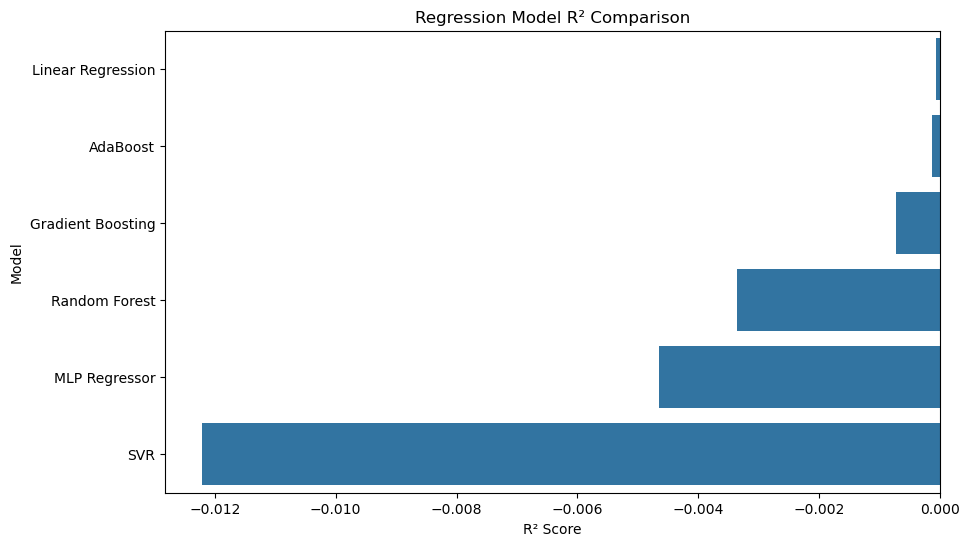

In [61]:
sorted_results = results.sort_values(
    "R2",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="R2",
    y="Model",
    data=sorted_results
)

plt.title(
    "Regression Model R² Comparison"
)

plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

In [63]:
#  Find Best Model Automatically

best_model = results.loc[
    results["R2"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model    Linear Regression
MAE                8.37926
MSE              100.20285
RMSE             10.010137
R2               -0.000069
Name: 0, dtype: object


In [65]:
#  Actual vs Predicted Values
# For example, using Random Forest:

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
})

comparison.head(20)

,Actual,Predicted
0,25,37.416281
1,26,38.492128
2,30,37.187596
3,27,36.790789
4,53,37.732030
5,30,37.608187
6,54,36.872065
7,49,36.083609
8,53,38.278494
9,31,37.418923


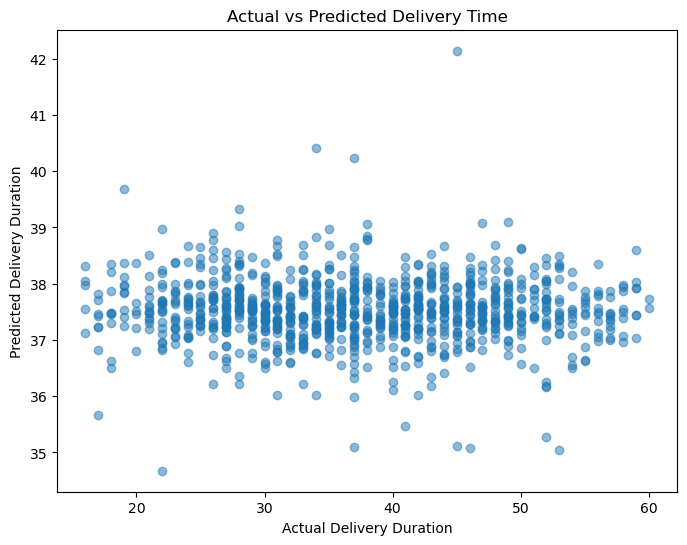

In [66]:
#  Actual vs Predicted Plot

plot_sample = comparison.sample(
    1000,
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_sample["Actual"],
    plot_sample["Predicted"],
    alpha=0.5
)

plt.xlabel(
    "Actual Delivery Duration"
)

plt.ylabel(
    "Predicted Delivery Duration"
)

plt.title(
    "Actual vs Predicted Delivery Time"
)

plt.show()

In [67]:
#  Feature Selection Using Random Forest
#  First transform the data:

X_train_transformed = (
    preprocessor
    .fit_transform(X_train)
)

In [68]:
#  Get feature names:

feature_names = (
    preprocessor
    .get_feature_names_out()
)

In [69]:
#  Train Random Forest:

feature_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

feature_rf.fit(
    X_train_transformed,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
#  Feature importance:


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
2,num__Delivery_Distance_km,0.264348
1,num__Total_Price,0.259189
3,num__Order_Hour,0.113124
4,num__Order_DayOfWeek,0.068758
0,num__Quantity,0.044245
13,cat__Payment_Method_Credit Card,0.016824
12,cat__Payment_Method_Cash,0.016681
14,cat__Payment_Method_Wallet,0.016526
17,cat__Driver_Vehicle_Motorbike,0.016465
16,cat__Driver_Vehicle_Car,0.016463


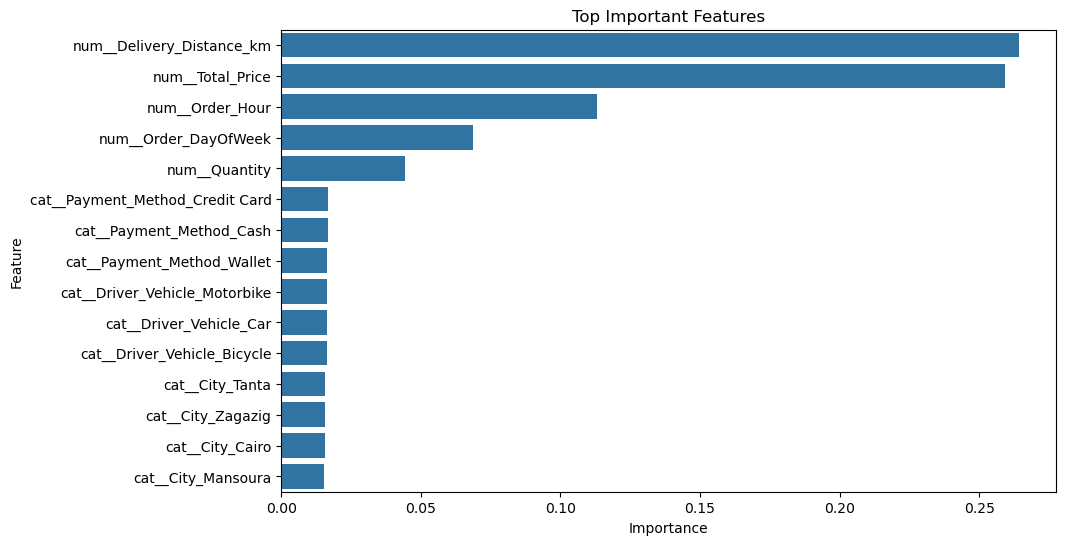

In [71]:
#   Visualization:

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title(
    "Top Important Features"
)

plt.show()

In [72]:
#   SelectKBest Feature Selection

selector = SelectKBest(
    score_func=f_regression,
    k=10
)

X_selected = selector.fit_transform(
    X_train_transformed,
    y_train
)

print(
    "Original Features:",
    X_train_transformed.shape[1]
)

print(
    "Selected Features:",
    X_selected.shape[1]
)

Original Features: 23
Selected Features: 10


Hyperparameter Tuning
We'll tune Random Forest using RandomizedSearchCV.

In [73]:
rf_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [75]:
#  Parameters:

param_grid = {
    "model__n_estimators": [
        100,
        150,
        200
    ],
    
    "model__max_depth": [
        10,
        15,
        20,
        None
    ],
    
    "model__min_samples_split": [
        2,
        5,
        10
    ],
    
    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [76]:
#  Tuning:

random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [10, 15, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 150, ...]}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [77]:
#  Best parameters:

print(
    "Best Parameters:",
    random_search.best_params_
)

print(
    "Best CV Score:",
    random_search.best_score_
)

Best Parameters: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 10}
Best CV Score: -0.0010862579120167748


# Evaluate Tuned Model

In [78]:
best_pipeline = random_search.best_estimator_

tuned_pred = best_pipeline.predict(
    X_test
)

tuned_result = evaluate_model(
    "Tuned Random Forest",
    y_test,
    tuned_pred
)


 Tuned Random Forest
MAE : 8.383967573165199
MSE : 100.34036279364403
RMSE: 10.01700368341971
R2  : -0.0014417663712487094


# Save the Model

In [80]:
#  This is very important because the entire preprocessing pipeline and ML model are saved together.

joblib.dump(
    best_pipeline,
    "food_delivery_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


# Load Saved Model

In [82]:
loaded_model = joblib.load(
    "food_delivery_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


#  Test with Unseen Data

In [84]:
#  Create a completely new food-order example:

new_order = pd.DataFrame({
    "Quantity": [2],
    "Total_Price": [250.0],
    "City": ["Alexandria"],
    "Payment_Method": ["Cash"],
    "Driver_Vehicle": ["Motorbike"],
    "Delivery_Distance_km": [5.5],
    "Traffic_Level": ["High"],
    "Driver_Availability": ["Online"],
    "Order_Hour": [19],
    "Order_DayOfWeek": [2]
})

In [85]:
#  Predict:

prediction = loaded_model.predict(
    new_order
)

print(
    "Predicted Delivery Duration:",
    round(prediction[0], 2),
    "minutes"
)

Predicted Delivery Duration: 38.99 minutes
